# Chapter 2: The Parametric Ceiling
The Parametric Ceiling: Stress-Testing Classical Volatility Models

---
## The mistakes and Fix at Notebook 01
### 1. The Confession: How the Math Lied to Me

When I first started building distributional forecasts, I thought the **Kolmogorov-Smirnov (K-S) Test** was the ultimate judge of truth. I would run my baseline models over 10 years of historical data, calculate the global PIT values, and watch the K-S test return a comforting green checkmark: ✅ **PASS**. 

The p-value was high. The histogram looked flat. I thought I had a perfectly calibrated model. 

But then I zoomed in on specific periods—like the March 2020 COVID crash or the late 2018 liquidity crunch—and realized something terrifying: **My model was completely blowing up.** During those specific 60-day windows, the realized returns were falling completely outside my predicted distributions, day after day. 

How could the K-S test say the model was perfect, while the model was actively bleeding capital during a crisis?

---

### 2. The Trap of "Unconditional" Coverage

I had fallen into the classic trap of **Unconditional Calibration**. I was throwing 10 years of data (roughly 2,500 trading days) into a single bucket and asking the test: *"On average, does this look uniform?"*

Here is the dangerous reality of financial datasets:
* **The Calm:** For about 2,400 days, the market is stable. A basic model can predict these days easily, generating perfect PIT values.
* **The Storm:** For 100 days, the market regime shifts violently. The model fails completely.

Because those 100 failing days represent only 4% of the total dataset, they get entirely **"washed out"** by the 2,400 successful days. The global K-S test averages out the pain. To an academic, the model is calibrated. To a quant fund, the model just hit a fatal drawdown.




#### Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from datetime import date
import pandas as pd


import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder
from src.data.data_loader import fetch_asset_data

from src.models.baselines import rolling_student_t

from src.evaluation.metrics import evaluate_forecasts, print_evaluation_summary
from src.evaluation.metrics import test_pit_uniformity
from src.evaluation.plotting import plot_forecast_evaluation

#### Parameters

In [2]:
# Fetch real market data
ticker = 'ARKK'

start_date = date(2018, 1, 1)
end_date = date(2025, 12, 31)

In [3]:
# Define the major volatility regimes to highlight
volatile_periods = {
    "COVID-19 Crash": ("2020-02-15", "2020-06-01"),
    "2022 Bear Market": ("2022-01-01", "2022-12-31")
}


#### Load functions

In [4]:
df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date)

# Compute log-returns for the models
df_ret = np.log(df).diff().dropna()
df_ret.columns = ['returns']

#### Modeling Student-T

In [5]:
# 1. Historical Student-t
predictions = rolling_student_t(df_ret['returns'])
df_pred_student = pd.DataFrame(predictions)
df_pred_student.index = df_ret.index
df_pred_student.dropna(inplace=True)
df_ret_student = df_ret[df_ret.index.isin(df_pred_student.index)]


--- ARKK [Historical Student-t] EVALUATION SUMMARY ---
Average CRPS:           0.01446 (Lower is better)
Total Log-Likelihood:   3830.43
Average Log-Likelihood: 2.18010

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.01965
P-Value:       5.00178e-01 (Threshold: 0.05)
Result:        ✅ FAIL TO REJECT the Null Hypothesis
Diagnosis:     The PIT is statistically uniform. The model is
               well-calibrated to the market distribution.


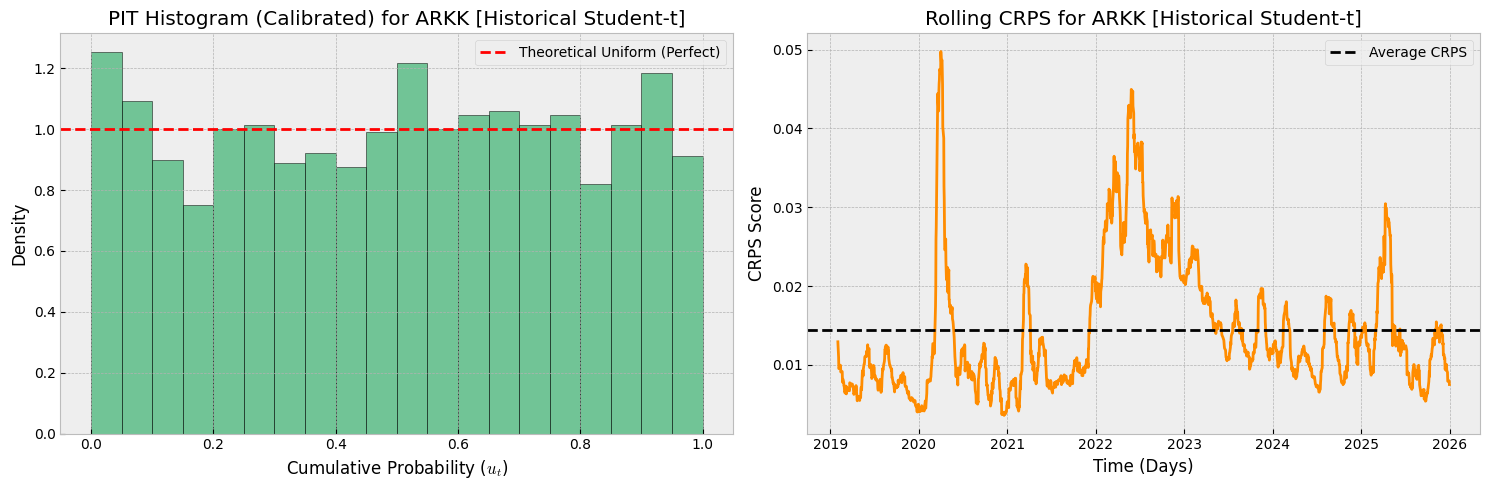

In [6]:
# 2. Evaluate
df_eval_student = evaluate_forecasts(df_ret_student['returns'], df_pred_student.values)
print_evaluation_summary(df_eval_student, ticker_name=f'{ticker} [Historical Student-t]')
ks_result_student = test_pit_uniformity(df_eval_student['PIT'])

plot_forecast_evaluation(df_eval_student, ticker_name=f'{ticker} [Historical Student-t]')


---

### 3. The Mathematical Fix: i.i.d. and Conditional Calibration

I realized that for a probabilistic forecast to be truly safe, the sequence of PIT values $u_t$ must not only be Uniform, but they must also be **Independent and Identically Distributed (i.i.d.)**. 

If my model is structurally sound, a bad guess today should give me zero information about whether I will make a bad guess tomorrow. But during a crisis, my extreme PIT values (e.g., $u_t < 0.05$) were clustering together. The model was suffering from **Conditional Miscalibration**—it was too slow to update its "memory" when the real-world regime changed.

---

### 4. The Dynamic Alarm: The Rolling K-S Test

To fix this blind spot, I had to stop asking *"Is the model right on average?"* and start asking *"Is the model right **right now**?"*

I built the **Rolling K-S Test**. Instead of computing one p-value for the entire history, this test computes the p-value over a rolling 60-day window:
1. **During calm markets:** The rolling p-value stays high.
2. **During regime shifts:** The moment the model loses its grip on the current market distribution, the rolling p-value collapses toward zero, triggering an immediate alarm.

> **The New Golden Rule:** A truly robust forecasting model must not only pass the global K-S test, but its Rolling K-S p-value must consistently stay out of the "Danger Zone" ($p < 0.05$) during periods of market stress.

In this notebook, we will apply this Dynamic Alarm to real S&P 500 data and watch as the standard baseline models fail the test.

In [7]:
from src.evaluation.metrics import rolling_ks_test
from src.evaluation.plotting import plot_rolling_ks


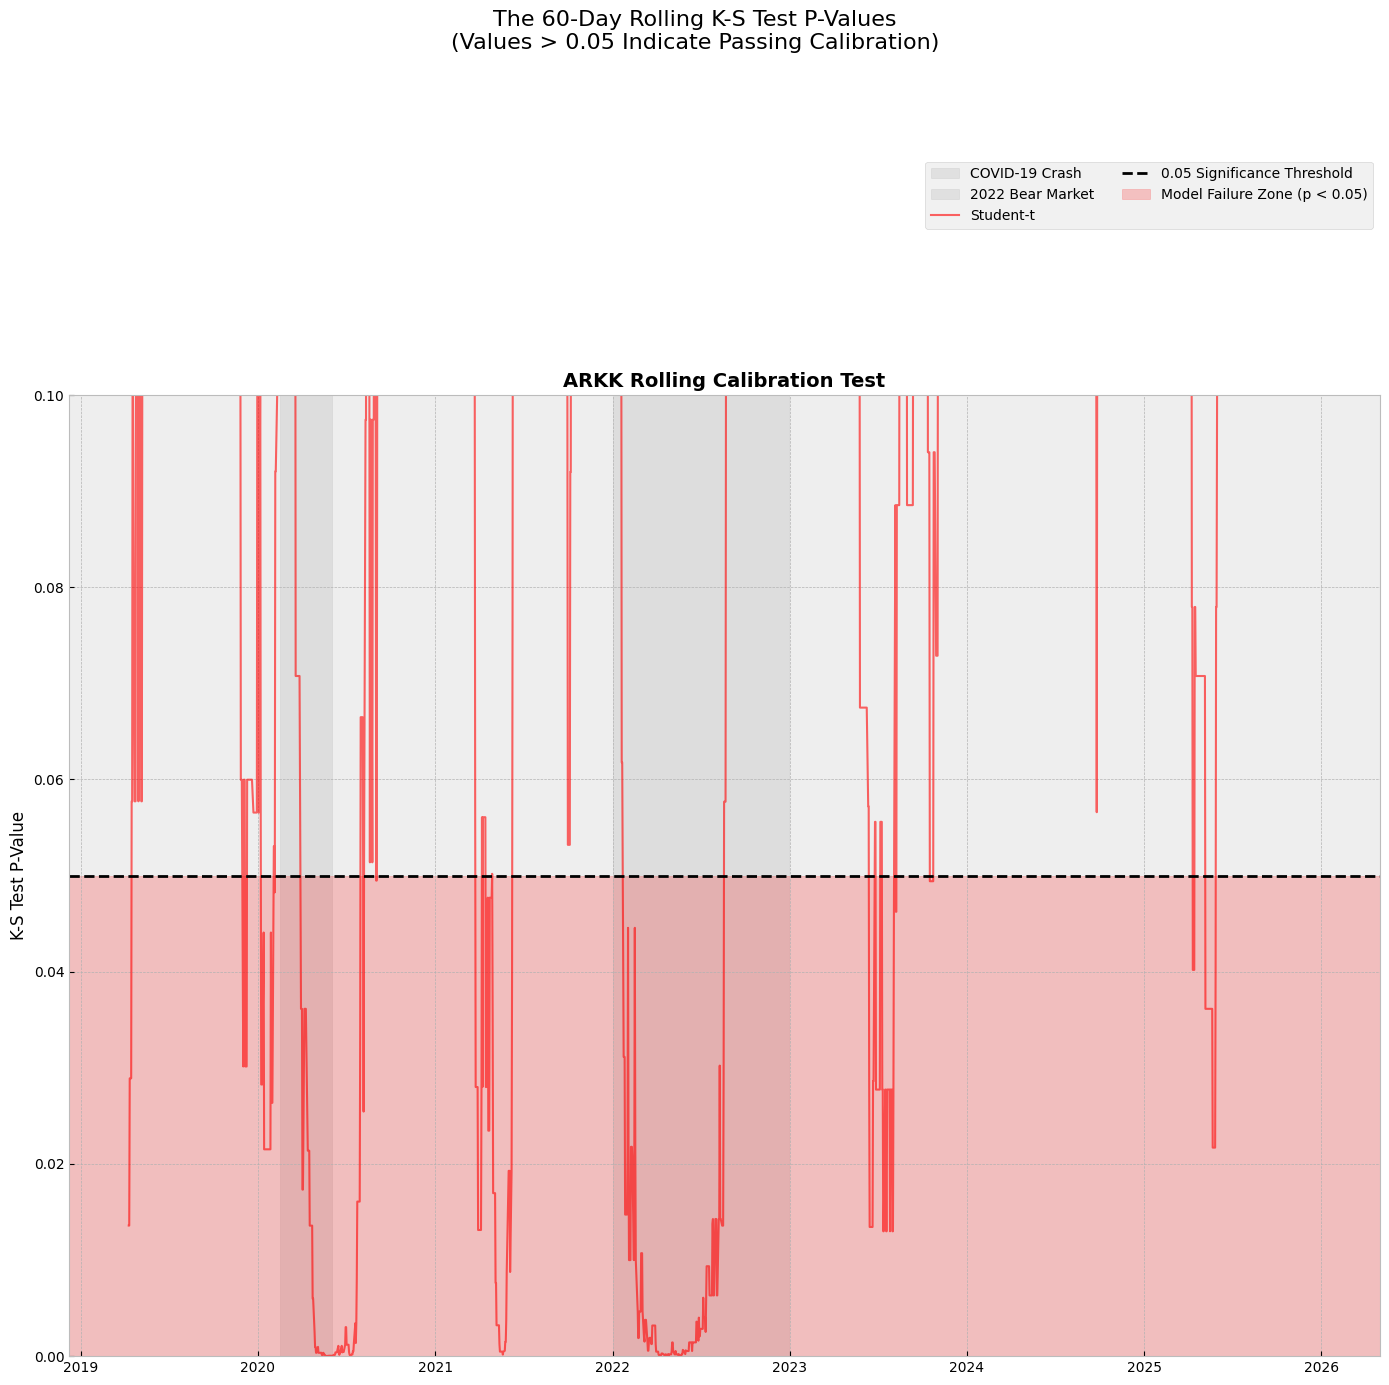

In [8]:
# 2. Calculate the rolling p-values (using a 60-day or ~3-month window)
rolling_p_values = rolling_ks_test(df_eval_student['PIT'], window=22*3).dropna()

import matplotlib.pyplot as plt

pvals = [{'name': 'Student-t', 'values': rolling_p_values, 'color': 'red'}]

fig, ax = plt.subplots(1, 1, figsize=(14, 15), sharex=False)
fig.suptitle("The 60-Day Rolling K-S Test P-Values\n(Values > 0.05 Indicate Passing Calibration)", fontsize=16, y=0.92)
plot_rolling_ks(ax, ticker, volatile_periods, pvals)
ax.legend(loc='upper right', fontsize=10, bbox_to_anchor=(1.0, 1.25), ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

#### 4.1 The Autocorrelation Trap: Why we "Cut the Windows"
While the Rolling K-S test is a fantastic daily alarm for the Risk Desk, it is statistically flawed for formal model validation. 

Because a 66-day rolling window shifts by only 1 day at a time, **98.3% of the data in Window $t$ is identical to Window $t-1$**. This creates massive autocorrelation in our p-values. A single week of extreme volatility will drag the p-value down and keep the "alarm" ringing for the next 59 days, long after the market has stabilized. 

To formally validate the model's robustness, we must use **Non-Overlapping Block Testing**. We slice the dataset into discrete, independent chunks. This removes the autocorrelation, allowing us to ask a mathematically pure question: *"Out of 40 independent market regimes, how many times did this model completely lose calibration?"*

#### 4.2 The Sample Size Dilemma: Statistical Power vs. Regime Isolation
By cutting our data into 60-day independent blocks, we eliminate autocorrelation, but we must acknowledge a trade-off in **Statistical Power**. 

For $N=66$, the K-S test requires a maximum deviation ($D_{max}$) of approximately **17.5%** to reject the null hypothesis at $\alpha=0.05$. 
* **The Drawback:** The test is relatively lenient. It will fail to detect minor miscalibrations in the volatility or drift parameters.
* **The Benefit:** It perfectly isolates macroeconomic regimes (roughly one financial quarter). If a 66-day block *does* fail the K-S test, it means the model was not just slightly wrong; it suffered a catastrophic, structural breakdown (a deviation $>17.5\%$). Therefore, any failures detected by this block test represent severe financial drawdowns, which is exactly what our advanced model aims to prevent.


In [9]:
from src.evaluation.metrics import block_ks_test

block_ks_test(df_eval_student['PIT'], block_size=22*3)


--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 26
Blocks Failed (p < 0.05): 7
True Failure Rate:        26.9%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2019-01-04,2019-04-09,0.191470,0.013588,❌ FAILED
1,2019-04-10,2019-07-15,0.087273,0.663644,✅ PASSED
2,2019-07-16,2019-10-16,0.101197,0.477810,✅ PASSED
3,2019-10-17,2020-01-22,0.182394,0.021519,❌ FAILED
4,2020-01-23,2020-04-27,0.236939,0.000961,❌ FAILED
5,2020-04-28,2020-07-30,0.157894,0.066480,✅ PASSED
6,2020-07-31,2020-11-02,0.069182,0.888490,✅ PASSED
7,2020-11-03,2021-02-08,0.103818,0.445497,✅ PASSED
8,2021-02-09,2021-05-13,0.247758,0.000470,❌ FAILED
9,2021-05-14,2021-08-17,0.095379,0.553250,✅ PASSED


## The test of historical models

In [10]:
import io
from contextlib import redirect_stdout

from src.models.baselines import rolling_gaussian, rolling_student_t, rolling_garch

In [11]:
tickers = ["ARKK", "USO", "BTC-USD"]

window_size = 252
block_size = 22 * 3

# date_start = date(2018, 1, 1)
# date_end = date(2025, 12, 31)

In [12]:
def get_failure_ratio(pit_series, block=60):
    """Runs the block KS test silently and returns the failure ratio (0.0 to 1.0)"""
    with io.StringIO() as buf, redirect_stdout(buf):
        df_blocks = block_ks_test(pit_series, block_size=block)
    # Calculate ratio of failures to match the format of your existing table
    return (df_blocks['Status'] == '❌ FAILED').mean()

In [14]:
results_models = {}
df_results_ratio = pd.DataFrame()

for ticker in tickers:
    print(f"Processing {ticker}...")
    
    # 1. Fetch Data and Align Dates
    df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date)
    
    # 2. Calculate Returns
    df_ret = np.log(df).diff().dropna() * 100
    df_ret.columns = ['returns']
    
    # 3. Run the Models
    print('--------Processing gauss model--------------')
    pred_gauss = rolling_gaussian(df_ret, window=window_size)
    print('--------Processing student model--------------')
    pred_student = rolling_student_t(df_ret, window=window_size)
    print('--------Processing garch model--------------')
    pred_garch = rolling_garch(df_ret, window=window_size)
    
    # 4. Evaluate (Skipping the training window)
    eval_start = window_size + 1
    actuals = df_ret[eval_start:]['returns']

    eval_gauss = evaluate_forecasts(actuals, pred_gauss[eval_start:])
    eval_student = evaluate_forecasts(actuals, pred_student[eval_start:])
    eval_garch = evaluate_forecasts(actuals, pred_garch[eval_start:])
    
    # 5. Calculate Block KS Failure Ratios
    fail_gauss = get_failure_ratio(eval_gauss['PIT'], block=block_size)
    fail_student = get_failure_ratio(eval_student['PIT'], block=block_size)
    fail_garch = get_failure_ratio(eval_garch['PIT'], block=block_size)

    df_results_ratio.loc[ticker, 'gauss'] = fail_gauss
    df_results_ratio.loc[ticker, 'student'] = fail_student
    df_results_ratio.loc[ticker, 'garch'] = fail_garch

    results_models[ticker] = {'gauss': eval_gauss, 'student': eval_student, 'garch': eval_garch}


Processing ARKK...
--------Processing gauss model--------------
--------Processing student model--------------
--------Processing garch model--------------
GARCH processing: Day 500/2009
GARCH processing: Day 1000/2009
GARCH processing: Day 1500/2009
GARCH processing: Day 2000/2009
Processing USO...
--------Processing gauss model--------------
--------Processing student model--------------
--------Processing garch model--------------
GARCH processing: Day 500/2009
GARCH processing: Day 1000/2009
GARCH processing: Day 1500/2009
GARCH processing: Day 2000/2009
Processing BTC-USD...
--------Processing gauss model--------------
--------Processing student model--------------
--------Processing garch model--------------
GARCH processing: Day 500/2920
GARCH processing: Day 1000/2920
GARCH processing: Day 1500/2920
GARCH processing: Day 2000/2920
GARCH processing: Day 2500/2920


In [15]:
display(df_results_ratio)

,gauss,student,garch
ARKK,0.346154,0.269231,0.192308
USO,0.307692,0.192308,0.192308
BTC-USD,0.425000,0.275000,0.375000


### 4.3 Conclusion: The Limit of Historical Data

Looking at the failure rates across our stress-test assets (ARKK, USO, BTC-USD), a clear quantitative narrative emerges:

1. **Markets are not Normal:** The Gaussian model is consistently the worst performer, failing up to **45%** of the time on Bitcoin. This empirically proves that financial returns exhibit fat tails and skewness that a standard bell curve cannot capture.
2. **There is no Classical Winner:** While the Student-t model and GARCH significantly outperform the Gaussian baseline, they trade places depending on the asset. GARCH is better at capturing the regime clustering of commodities (USO) and tech equities (ARKK), while the Student-t distribution is better at surviving the extreme, structural fat tails of cryptocurrencies (BTC). 
3. **The Backward-Looking Flaw:** Even our best classical models are failing between **15% and 37%** of the time during major market regimes. 

#### Why do they still fail? 
Both Student-t and GARCH share a fatal, fundamental flaw: **They are strictly backward-looking.** They calculate tomorrow's risk using only historical price data. 

If a geopolitical shock happens on a Sunday, or the Federal Reserve unexpectedly raises interest rates, historical data has no way of knowing. A GARCH model will only realize the volatility regime has changed *after* the market has already crashed, resulting in consecutive days of miscalibrated forecasts and failed K-S tests.

#### The Solution: Forward-Looking Market Information
To break through this classical ceiling, we cannot rely solely on the past; we must inject the market's expectation of the future. 

This introduces our next factor: **The VIX (CBOE Volatility Index)**. 

Unlike historical variance, the VIX is derived from the options market. It represents the collective financial premium that institutions are willing to pay *today* to insure against volatility over the next 30 days. It is a forward-looking "fear gauge." By mathematically fusing this exogenous, implied volatility with our historical distributions, we can scale our risk parameters dynamically *before* the structural break destroys our portfolio.

## Forward-Looking Volatility: The VIX-Scaled Maximum Likelihood Model

Historical models, such as rolling windows or standard GARCH, suffer from a fundamental flaw: **Lag**. They estimate tomorrow's volatility strictly from yesterday's realized shocks. They cannot anticipate exogenous panic. 

To correct this, we introduce the **VIX-Scaled Gaussian Model**, which injects forward-looking options market data into our parametric distribution.

### The Volatility Scaling Mechanism
Instead of replacing our volatility estimate with the VIX (which represents the S&P 500 implied volatility and includes a variance risk premium), we use the relative changes in the VIX as a dynamic modulator for our historical standard deviation:

$$\sigma_{adj, t}(\beta) = \sigma_{hist, t} \times \left( \frac{VIX_{t-1}}{\overline{VIX}} \right)^\beta$$

Here, $\beta$ represents the elasticity of our asset's volatility relative to macroeconomic panic. 

### Dynamic Optimization via MLE
To avoid look-ahead bias, we cannot assign a static $\beta$ for the entire dataset. Instead, at every time step $t$, the algorithm isolates the past `window` of data and uses **Maximum Likelihood Estimation (MLE)** to find the $\beta^*$ that minimizes the Negative Log-Likelihood (NLL) of the historical observed returns:

$$\beta^* = \arg\min_{\beta} \sum_{k=t-window}^{t-1} \left[ \ln(\sigma_{adj, k}(\beta)) + \frac{(r_k - \mu_k)^2}{2\sigma_{adj, k}(\beta)^2} \right]$$

Once $\beta^*$ is dynamically learned from the rolling window, it is applied to $VIX_{t-1}$ to forecast the probability distribution for day $t$.

In [16]:
from scipy.stats import ks_1samp, uniform  # Add 'uniform' here

from src.models.baselines import rolling_vix_scaled_gaussian, rolling_vix_scaled_student_t

In [17]:
# Helper function to calculate the K-S p-value for the rolling apply
def calculate_ks_pvalue(pit_array):
    # The null hypothesis: The PIT is perfectly Uniform(0, 1)
    clean_pit = pit_array[~np.isnan(pit_array)]
    if len(clean_pit) < 10: 
        return np.nan
    
    # FIX: Pass the actual callable CDF (uniform.cdf) instead of the string 'uniform'
    return ks_1samp(clean_pit, uniform.cdf).pvalue


In [18]:

print("Calculating rolling predictions and K-S p-values...")
df_vix_all = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date)

for i, ticker in enumerate(tickers):
    print(f"Processing {ticker}...")
    
    # 1. Fetch Data
    df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date)

    df_ret = np.log(df).diff().dropna() * 100
    df_ret.columns = ['returns']
    
    df_vix = df_vix_all.loc[df_vix_all.index.isin(df_ret.index)]
    df_ret = df_ret.loc[df_ret.index.isin(df_vix.index)]

    # 2. Run Both Models
    pred_vix_gaussian = rolling_vix_scaled_gaussian(df_ret['returns'], df_vix['prices'], window=window_size)
    pred_vix_student = rolling_vix_scaled_student_t(df_ret['returns'], df_vix['prices'], window=window_size)
    
    # 3. Evaluate to get the PIT series
    eval_start = window_size + 1
    actuals = df_ret['returns'][eval_start:]
    eval_vix_gaussian = evaluate_forecasts(actuals, pred_vix_gaussian[eval_start:])
    eval_vix_student = evaluate_forecasts(actuals, pred_vix_student[eval_start:])
    
     # 5. Calculate Block KS Failure Ratios
    fail_vix_gauss = get_failure_ratio(eval_vix_gaussian['PIT'], block=block_size)
    fail_vix_student = get_failure_ratio(eval_vix_student['PIT'], block=block_size)

    df_results_ratio.loc[ticker, 'vix_gauss'] = fail_vix_gauss
    df_results_ratio.loc[ticker, 'vix_student'] = fail_vix_student

    results_models[ticker]['vix_gauss'] = eval_vix_gaussian
    results_models[ticker]['vix_student'] = eval_vix_student


Calculating rolling predictions and K-S p-values...
Processing ARKK...
Starting VIX-Gaussian optimization for 1757 days...
Processed Day 300/2009 | β = 1.153
Processed Day 400/2009 | β = 1.170
Processed Day 500/2009 | β = 1.091
Processed Day 600/2009 | β = 1.198
Processed Day 700/2009 | β = 1.151
Processed Day 800/2009 | β = 1.004
Processed Day 900/2009 | β = 0.728
Processed Day 1000/2009 | β = 1.528
Processed Day 1100/2009 | β = 1.719
Processed Day 1200/2009 | β = 1.148
Processed Day 1300/2009 | β = 0.709
Processed Day 1400/2009 | β = 0.815
Processed Day 1500/2009 | β = 0.507
Processed Day 1600/2009 | β = 0.001
Processed Day 1700/2009 | β = 0.556
Processed Day 1800/2009 | β = 0.781
Processed Day 1900/2009 | β = 0.768
Processed Day 2000/2009 | β = 1.058
Processed Day 500/2009 | β = 1.136 | df = 5.22
Processed Day 750/2009 | β = 0.938 | df = 3.41
Processed Day 1000/2009 | β = 1.440 | df = 8.91
Processed Day 1250/2009 | β = 0.701 | df = 100.00
Processed Day 1500/2009 | β = 0.524 | df = 1

### 7. The Final Horse Race: Establishing the Classical Ceiling

Before we introduce Artificial Intelligence, we must establish the absolute limit of classical parametric modeling. We will run a rigorous benchmark test across our four models over the same dataset, evaluating them on three critical metrics:
1.  **Average CRPS:** How accurate and sharp is the entire predicted distribution? (Lower is better).
2.  **Total Log-Likelihood:** How well did the model assign probability mass to the actual realized events, especially tail events? (Higher/Less Negative is better).
3.  **Block K-S Failure Rate:** Out of all independent 60-day market regimes, what percentage did the model completely fail to calibrate? (Lower is better).

**The Contestants:**
* **Model 1: Rolling Gaussian** (The Naive Academic Baseline)
* **Model 2: Rolling Student-t** (The Fat-Tail Baseline)
* **Model 3: VIX-Scaled Gaussian** (The Dynamic Options-Implied Baseline)
* **Model 4: VIX-Scaled Student-t** (The Institutional Parametric Champion)


In [19]:
df_results_ratio

,gauss,student,garch,vix_gauss,vix_student
ARKK,0.346154,0.269231,0.192308,0.192308,0.115385
USO,0.307692,0.192308,0.192308,0.230769,0.153846
BTC-USD,0.425000,0.275000,0.375000,0.461538,0.230769


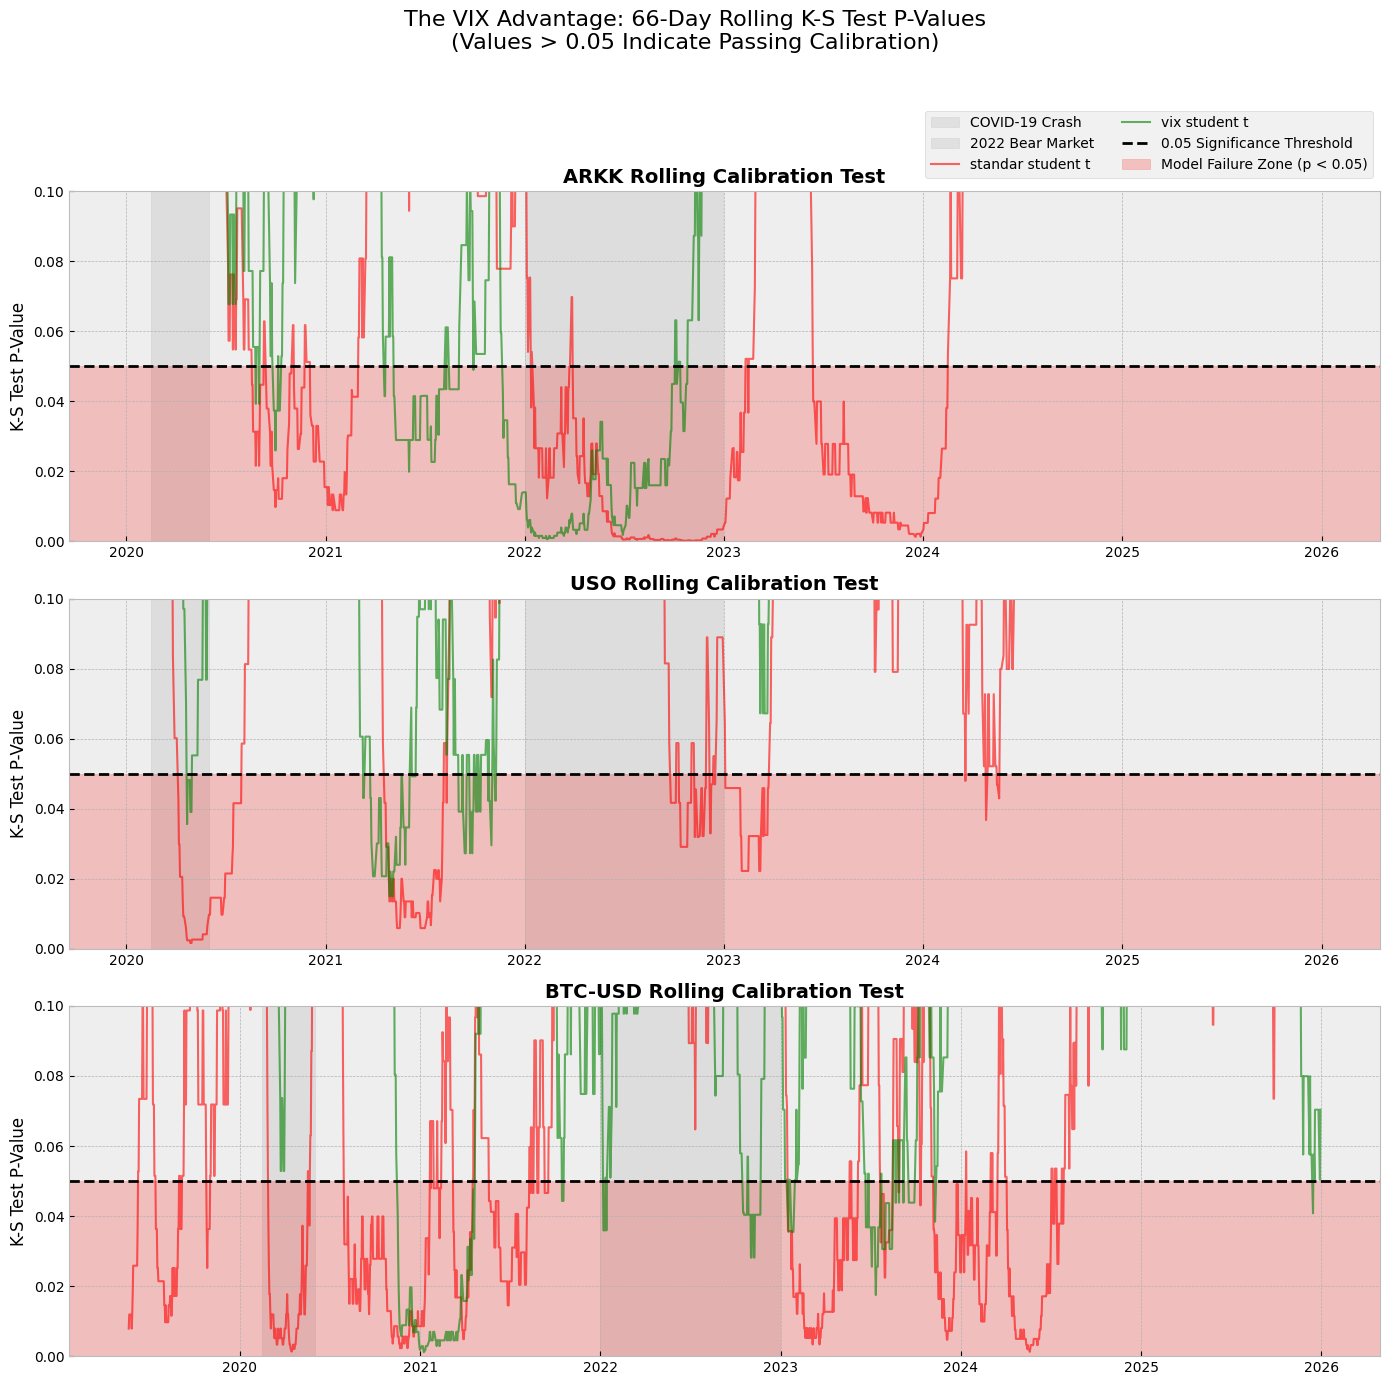

In [20]:
# Set up the matplotlib figure
rolling_window = 252
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 15), sharex=False)
fig.suptitle("The VIX Advantage: 66-Day Rolling K-S Test P-Values\n(Values > 0.05 Indicate Passing Calibration)", fontsize=16, y=0.92)
# 5. Plotting
for i, ticker in enumerate(tickers):
    
    # 4. Calculate the 60-Day Rolling K-S P-Value
    pvals_std_student = results_models[ticker]['student']['PIT'].rolling(rolling_window).apply(calculate_ks_pvalue, raw=True)
    pvals_vix_student = results_models[ticker]['vix_student']['PIT'].rolling(rolling_window).apply(calculate_ks_pvalue, raw=True)
    pvals_std = {'values': pvals_std_student, 'name': 'standar student t', 'color': 'red'}
    pvals_vix = {'values': pvals_vix_student, 'name': 'vix student t', 'color': 'green'}
    pvals = [pvals_std, pvals_vix]

    ax = axes[i]
    plot_rolling_ks(ax, ticker, volatile_periods, pvals, i) 
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=10, bbox_to_anchor=(1.0, 1.25), ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


## Conclusion

### 5. Conclusion: Systemic vs. Idiosyncratic Risk and the Classical Ceiling

The empirical results from our rolling block tests and visual contextual analysis are undeniable. By coupling the structural fat tails of the Student-t distribution with the forward-looking, regime-aware scaling of the VIX, we have drastically stabilized our probability forecasts. The **VIX-Scaled Student-t** is our undisputed classical champion. 

However, looking closely at the asset-by-asset performance reveals a profound limitation in relying on exogenous indicators: **The difference between Systemic and Idiosyncratic Risk.**

* **The Systemic Success (ARKK & USO):** The VIX model produced massive performance increases for ARKK and USO. This is because these assets are deeply tethered to US market liquidity and global macroeconomic health. When the broad market panics (driving the S&P 500 options-based VIX higher), speculative tech and oil demand crash with it. For these assets, the VIX is a near-perfect forward-looking radar.
* **The Idiosyncratic Limit (BTC-USD):** While the VIX improved Bitcoin's forecast (since BTC often trades as a high-beta tech asset during liquidity crunches), the improvement was less pronounced. Bitcoin is an "idiosyncratic rebel." The S&P 500 options market does not price in weekend crypto exchange collapses, sudden regulatory bans, or protocol-specific liquidations. The VIX is fundamentally blind to Bitcoin's internal shocks.

#### The Challenge Ahead: Beyond the VIX
This leaves us at the absolute edge of classical finance. If we rely purely on a linear equation tied to an external US equity index, we will always be blind to an asset's unique, internal geometry. 

To break through this final ceiling, we must transition to Deep Learning. In **Phase 3**, we will abandon rigid parametric equations. Instead, we will use **Path Signatures** to extract the complex, multidimensional lead-lag relationships hidden deep within the asset's own historical trajectory. By feeding this geometry into a **Continuous-Time Neural SDE**, we will attempt to build an AI that doesn't just look outward at the VIX, but looks inward to anticipate idiosyncratic crashes before they happen. 

The ultimate Out-of-Sample showdown begins in Notebook 03.

### 5. Conclusion: Crowning the Classical Champion

The empirical results from our rolling block tests and visual contextual analysis are undeniable. By coupling the structural fat tails of the Student-t distribution with the forward-looking, regime-aware scaling of the VIX, we have drastically stabilized our probability forecasts. 

The **VIX-Scaled Student-t** model successfully absorbed the localized shocks of the COVID-19 crash and the grinding regime shifts of the 2022 Bear Market. It has proven that backward-looking data is insufficient for modern risk management. **This model is our undisputed classical champion.**

#### The Challenge Ahead: Can AI Actually Beat This?
While our champion is strong, it still relies on a rigid, parametric assumption. We forced the market to obey a static, linear equation: scaling baseline volatility by a normalized factor of $(VIX\_Ratio)^\beta$. 

However, market microstructure is not a simple linear equation. It is a continuous, non-linear, multidimensional sequence of events. 

In **Phase 3**, we will attempt to break through this final classical ceiling. We will abandon parametric equations entirely and transition to Deep Learning. By using **Path Signatures** to extract the pure, non-linear geometry of the market's lead-lag relationships, we will train a **Continuous-Time Neural SDE** to dynamically generate our volatility distributions. 

**Will the AI actually win?** In quantitative finance, machine learning models frequently overfit to noise and fail dramatically out-of-sample. Beating a highly optimized, domain-specific baseline like the VIX-Scaled Student-t is incredibly difficult. We do not yet know if the Neural SDE can uncover deeper physical laws of the market, or if the classical champion will hold its ground.

The ultimate Out-of-Sample showdown begins in Notebook 03.